In [1]:
!pip install -Uq numpy

In [2]:
!pip install -Uq matplotlib

In [3]:
!pip install -Uq pymcel

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [5]:
# Definición del sistema: Sol fijo, Tierra y Apophis
sistema = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
]

Se asigna al asteroide una posición inicial ligeramente mayor que la de la Tierra y una velocidad cercana a la velocidad orbital circular, con el fin de generar una órbita elíptica que permita estudiar posibles encuentros cercanos

In [6]:
def aceleraciones(sistema):
    n = len(sistema)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo, no recibe aceleraciones
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema[j]['r'] - sistema[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [7]:
def paso_leapfrog(sistema, dt):
    a = aceleraciones(sistema)
    for i in range(1, len(sistema)): 
        sistema[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema)):  # No mover Sol
        sistema[i]['r'] += sistema[i]['v'] * dt

    a_new = aceleraciones(sistema)
    for i in range(1, len(sistema)):  
        sistema[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.001
pasos = 20000

trayectorias = [[] for _ in sistema]

for _ in range(pasos):
    paso_leapfrog(sistema, dt)
    for i in range(len(sistema)):
        trayectorias[i].append(sistema[i]['r'].copy())


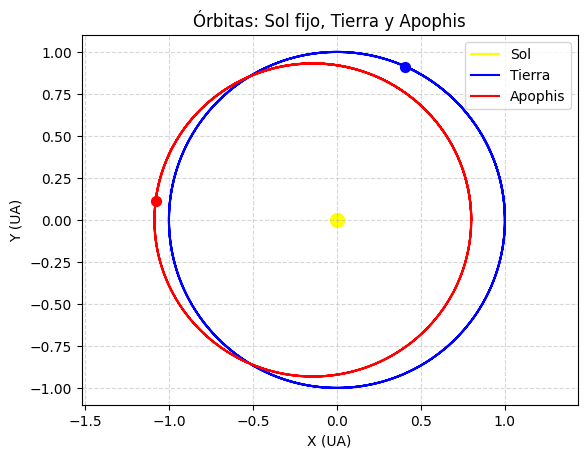

In [8]:
colors = ['yellow', 'blue', 'red']
labels = ['Sol', 'Tierra', 'Apophis']

for i in range(len(sistema)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
    plt.scatter(tray[-1,0], tray[-1,1], color=colors[i], s=50)  

plt.scatter(0, 0, color='yellow', s=100)  # Sol destacado en el origen
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra y Apophis')
plt.show()


Añaniendo la luna al sistema